In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
np.random.seed(42)

n = 5000

departments = [
    "Emergency",
    "Cardiology",
    "Orthopedics",
    "Neurology",
    "Oncology",
    "Pediatrics",
    "General Medicine"
]

diagnosis_groups = [
    "Respiratory",
    "Cardiovascular",
    "Trauma",
    "Neurological",
    "Cancer",
    "Infection",
    "Other"
]

insurance_types = [
    "Public",
    "Private",
    "Self-pay"
]

data = pd.DataFrame({
    "patient_id": np.arange(1, n + 1),
    "age": np.random.randint(1, 90, n),
    "gender": np.random.choice(["Female", "Male"], n, p=[0.53, 0.47]),
    "department": np.random.choice(
        departments,
        n,
        p=[0.28, 0.13, 0.12, 0.10, 0.09, 0.13, 0.15]
    ),
    "diagnosis_group": np.random.choice(diagnosis_groups, n),
    "insurance_type": np.random.choice(
        insurance_types,
        n,
        p=[0.48, 0.42, 0.10]
    )
})

data["admission_date"] = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 365, n),
    unit="D"
)

wait_base = {
    "Emergency": 75,
    "Cardiology": 45,
    "Orthopedics": 50,
    "Neurology": 55,
    "Oncology": 40,
    "Pediatrics": 35,
    "General Medicine": 60
}

data["wait_time_minutes"] = data["department"].map(wait_base) + np.random.normal(0, 18, n)
data["wait_time_minutes"] = data["wait_time_minutes"].clip(lower=5).round(0).astype(int)

los_base = {
    "Emergency": 2.5,
    "Cardiology": 4.5,
    "Orthopedics": 3.8,
    "Neurology": 5.0,
    "Oncology": 6.0,
    "Pediatrics": 2.0,
    "General Medicine": 3.2
}

data["length_of_stay_days"] = data["department"].map(los_base) + np.random.normal(0, 1.4, n)
data["length_of_stay_days"] = data["length_of_stay_days"].clip(lower=0.5).round(1)

data["readmitted"] = np.where(
    (
        (data["length_of_stay_days"] > 5) |
        (data["department"].isin(["Cardiology", "Oncology", "Neurology"]))
    ),
    np.random.choice([0, 1], n, p=[0.78, 0.22]),
    np.random.choice([0, 1], n, p=[0.90, 0.10])
)

data["satisfaction_score"] = (
    9
    - (data["wait_time_minutes"] / 40)
    - (data["length_of_stay_days"] / 10)
    + np.random.normal(0, 0.8, n)
)

data["satisfaction_score"] = data["satisfaction_score"].clip(lower=1, upper=10).round(1)

data["discharge_date"] = data["admission_date"] + pd.to_timedelta(
    data["length_of_stay_days"].round(0).astype(int),
    unit="D"
)

data.head()

,patient_id,age,gender,department,diagnosis_group,insurance_type,admission_date,wait_time_minutes,length_of_stay_days,readmitted,satisfaction_score,discharge_date
0,1,52,Male,Cardiology,Infection,Private,2025-12-07,51,0.5,0,7.4,2025-12-07
1,2,15,Male,General Medicine,Other,Private,2025-10-26,63,3.8,0,6.9,2025-10-30
2,3,72,Female,Pediatrics,Other,Private,2025-03-17,43,1.5,0,8.8,2025-03-19
3,4,61,Male,Neurology,Respiratory,Private,2025-05-20,58,4.7,0,7.1,2025-05-25
4,5,21,Female,Orthopedics,Respiratory,Public,2025-11-02,58,1.1,1,7.4,2025-11-03


In [3]:
Path("../data/raw").mkdir(parents=True, exist_ok=True)

data.to_csv("../data/raw/healthcare_operations.csv", index=False)

print("Base sintética salva com sucesso.")

Base sintética salva com sucesso.


In [4]:
df = pd.read_csv("../data/raw/healthcare_operations.csv")

df.head()

,patient_id,age,gender,department,diagnosis_group,insurance_type,admission_date,wait_time_minutes,length_of_stay_days,readmitted,satisfaction_score,discharge_date
0,1,52,Male,Cardiology,Infection,Private,2025-12-07,51,0.5,0,7.4,2025-12-07
1,2,15,Male,General Medicine,Other,Private,2025-10-26,63,3.8,0,6.9,2025-10-30
2,3,72,Female,Pediatrics,Other,Private,2025-03-17,43,1.5,0,8.8,2025-03-19
3,4,61,Male,Neurology,Respiratory,Private,2025-05-20,58,4.7,0,7.1,2025-05-25
4,5,21,Female,Orthopedics,Respiratory,Public,2025-11-02,58,1.1,1,7.4,2025-11-03


In [5]:
df.shape

(5000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   object 
 3   department           5000 non-null   object 
 4   diagnosis_group      5000 non-null   object 
 5   insurance_type       5000 non-null   object 
 6   admission_date       5000 non-null   object 
 7   wait_time_minutes    5000 non-null   int64  
 8   length_of_stay_days  5000 non-null   float64
 9   readmitted           5000 non-null   int64  
 10  satisfaction_score   5000 non-null   float64
 11  discharge_date       5000 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 468.9+ KB


In [7]:
df.isna().sum()

patient_id             0
age                    0
gender                 0
department             0
diagnosis_group        0
insurance_type         0
admission_date         0
wait_time_minutes      0
length_of_stay_days    0
readmitted             0
satisfaction_score     0
discharge_date         0
dtype: int64

## Contexto do projeto

Este projeto usa uma base sintética de atendimentos em saúde para simular uma análise operacional.

A base contém informações de pacientes, departamento de atendimento, tempo de espera, tempo de permanência, readmissão, tipo de convênio e satisfação do paciente.

O objetivo é analisar indicadores que poderiam ser acompanhados por uma área de operações, qualidade ou BI em saúde.

In [8]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])

df["readmission_status"] = df["readmitted"].map({
    0: "No",
    1: "Yes"
})

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 17, 35, 50, 65, 100],
    labels=["0-17", "18-35", "36-50", "51-65", "65+"]
)

df["wait_time_group"] = pd.cut(
    df["wait_time_minutes"],
    bins=[0, 30, 60, 90, 180],
    labels=["Até 30 min", "30-60 min", "60-90 min", "Acima de 90 min"]
)

df[[
    "age",
    "age_group",
    "department",
    "wait_time_minutes",
    "wait_time_group",
    "length_of_stay_days",
    "readmission_status",
    "satisfaction_score"
]].head()

,age,age_group,department,wait_time_minutes,wait_time_group,length_of_stay_days,readmission_status,satisfaction_score
0,52,51-65,Cardiology,51,30-60 min,0.5,No,7.4
1,15,0-17,General Medicine,63,60-90 min,3.8,No,6.9
2,72,65+,Pediatrics,43,30-60 min,1.5,No,8.8
3,61,51-65,Neurology,58,30-60 min,4.7,No,7.1
4,21,18-35,Orthopedics,58,30-60 min,1.1,Yes,7.4


In [9]:
total_patients = df["patient_id"].nunique()
avg_wait_time = df["wait_time_minutes"].mean()
avg_los = df["length_of_stay_days"].mean()
readmission_rate = df["readmitted"].mean() * 100
avg_satisfaction = df["satisfaction_score"].mean()

print(f"Total de pacientes: {total_patients:,}")
print(f"Tempo médio de espera: {avg_wait_time:.1f} minutos")
print(f"Tempo médio de permanência: {avg_los:.1f} dias")
print(f"Taxa de readmissão: {readmission_rate:.2f}%")
print(f"Satisfação média: {avg_satisfaction:.1f}")

Total de pacientes: 5,000
Tempo médio de espera: 55.5 minutos
Tempo médio de permanência: 3.5 dias
Taxa de readmissão: 14.10%
Satisfação média: 7.3


In [10]:
department_summary = (
    df
    .groupby("department")
    .agg(
        patients=("patient_id", "count"),
        avg_wait_time=("wait_time_minutes", "mean"),
        avg_los=("length_of_stay_days", "mean"),
        readmission_rate=("readmitted", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
)

department_summary["readmission_rate"] = department_summary["readmission_rate"] * 100

department_summary = department_summary.round(2)

department_summary.sort_values("avg_wait_time", ascending=False)

,department,patients,avg_wait_time,avg_los,readmission_rate,avg_satisfaction
1,Emergency,1400,74.66,2.55,10.21,6.90
2,General Medicine,761,59.87,3.23,10.51,7.17
3,Neurology,521,54.83,4.97,19.58,7.17
5,Orthopedics,612,50.60,3.74,11.27,7.32
0,Cardiology,665,44.09,4.52,22.41,7.45
4,Oncology,424,39.59,5.95,22.41,7.51
6,Pediatrics,617,35.30,2.09,10.86,7.92


In [12]:
Path("../outputs/charts").mkdir(parents=True, exist_ok=True)
Path("../outputs/tables").mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [13]:
def add_bar_labels_horizontal(ax, fmt="{:.0f}", offset=5):
    for p in ax.patches:
        value = p.get_width()
        ax.annotate(
            fmt.format(value),
            (value, p.get_y() + p.get_height() / 2),
            xytext=(offset, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9
        )


def add_bar_labels_vertical(ax, fmt="{:.1f}", offset=5):
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(
            fmt.format(value),
            (p.get_x() + p.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

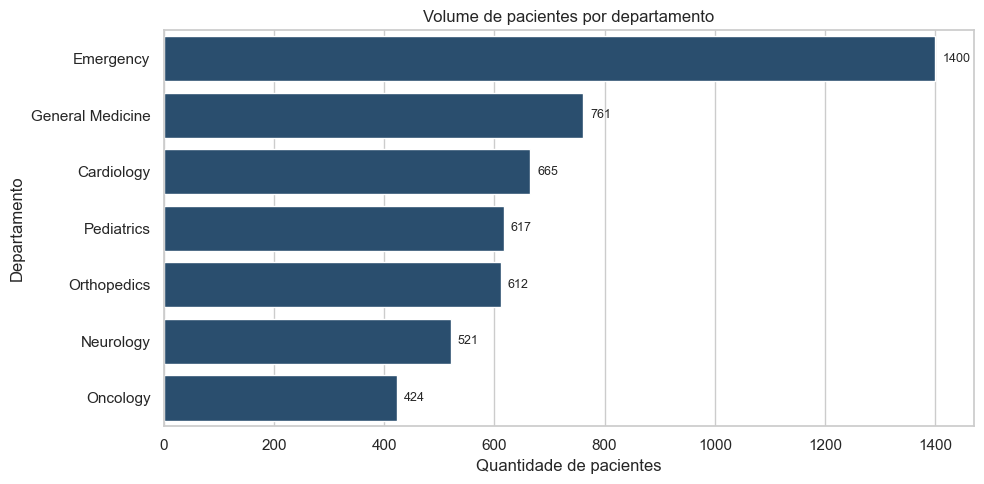

In [14]:
patients_by_department = department_summary.sort_values("patients", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=patients_by_department,
    x="patients",
    y="department",
    color="#1F4E79"
)

plt.title("Volume de pacientes por departamento")
plt.xlabel("Quantidade de pacientes")
plt.ylabel("Departamento")

add_bar_labels_horizontal(ax, "{:.0f}")

plt.tight_layout()
plt.savefig("../outputs/charts/patients_by_department.png", dpi=150)
plt.show()

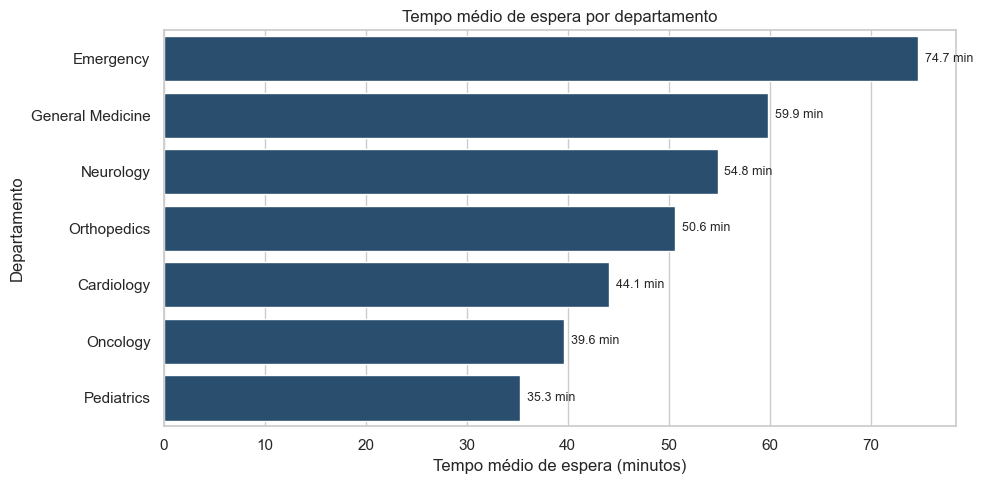

In [15]:
wait_by_department = department_summary.sort_values("avg_wait_time", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=wait_by_department,
    x="avg_wait_time",
    y="department",
    color="#1F4E79"
)

plt.title("Tempo médio de espera por departamento")
plt.xlabel("Tempo médio de espera (minutos)")
plt.ylabel("Departamento")

add_bar_labels_horizontal(ax, "{:.1f} min")

plt.tight_layout()
plt.savefig("../outputs/charts/avg_wait_time_by_department.png", dpi=150)
plt.show()

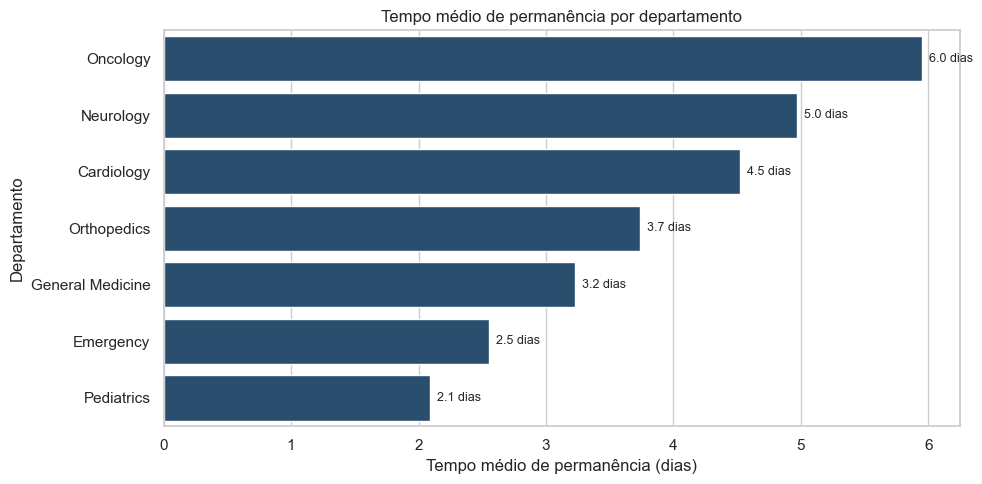

In [16]:
los_by_department = department_summary.sort_values("avg_los", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=los_by_department,
    x="avg_los",
    y="department",
    color="#1F4E79"
)

plt.title("Tempo médio de permanência por departamento")
plt.xlabel("Tempo médio de permanência (dias)")
plt.ylabel("Departamento")

add_bar_labels_horizontal(ax, "{:.1f} dias")

plt.tight_layout()
plt.savefig("../outputs/charts/avg_length_of_stay_by_department.png", dpi=150)
plt.show()

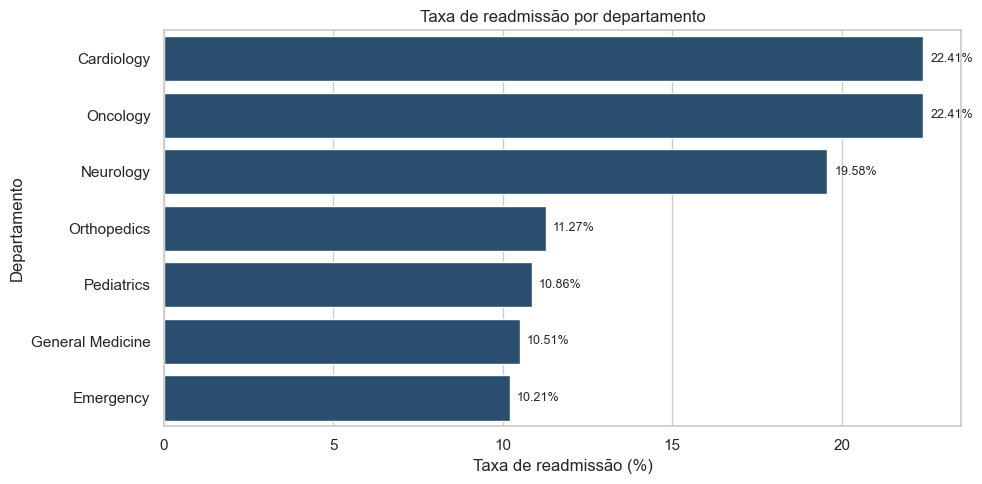

In [17]:
readmission_by_department = department_summary.sort_values("readmission_rate", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=readmission_by_department,
    x="readmission_rate",
    y="department",
    color="#1F4E79"
)

plt.title("Taxa de readmissão por departamento")
plt.xlabel("Taxa de readmissão (%)")
plt.ylabel("Departamento")

add_bar_labels_horizontal(ax, "{:.2f}%")

plt.tight_layout()
plt.savefig("../outputs/charts/readmission_rate_by_department.png", dpi=150)
plt.show()

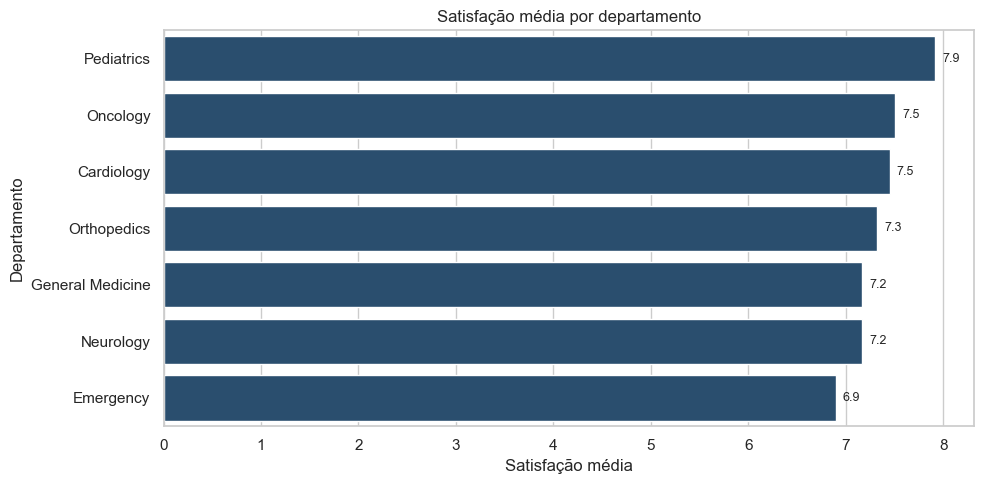

In [18]:
satisfaction_by_department = department_summary.sort_values("avg_satisfaction", ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=satisfaction_by_department,
    x="avg_satisfaction",
    y="department",
    color="#1F4E79"
)

plt.title("Satisfação média por departamento")
plt.xlabel("Satisfação média")
plt.ylabel("Departamento")

add_bar_labels_horizontal(ax, "{:.1f}")

plt.tight_layout()
plt.savefig("../outputs/charts/avg_satisfaction_by_department.png", dpi=150)
plt.show()

c:\Users\gabri\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


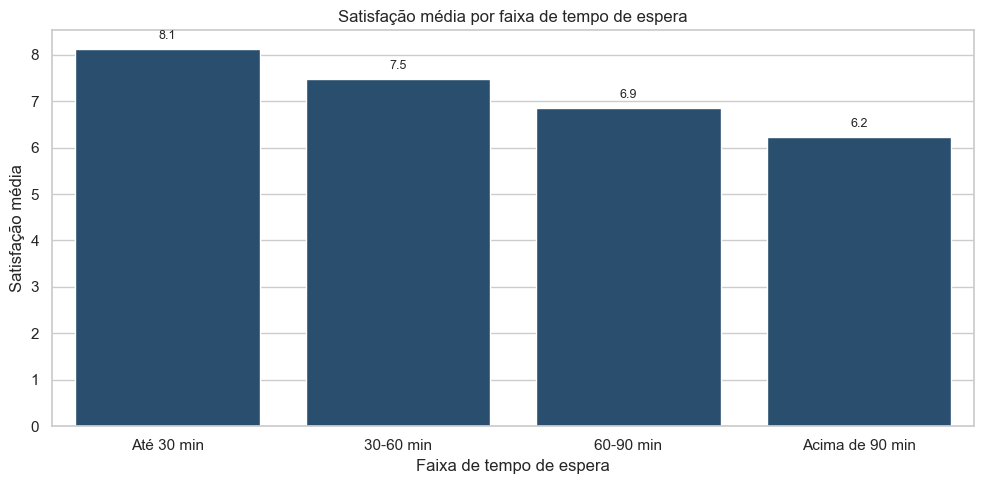

In [19]:
satisfaction_by_wait = (
    df
    .groupby("wait_time_group", observed=False)
    .agg(
        patients=("patient_id", "count"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
    .round(2)
)

wait_order = ["Até 30 min", "30-60 min", "60-90 min", "Acima de 90 min"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=satisfaction_by_wait,
    x="wait_time_group",
    y="avg_satisfaction",
    order=wait_order,
    color="#1F4E79"
)

plt.title("Satisfação média por faixa de tempo de espera")
plt.xlabel("Faixa de tempo de espera")
plt.ylabel("Satisfação média")

add_bar_labels_vertical(ax, "{:.1f}")

plt.tight_layout()
plt.savefig("../outputs/charts/satisfaction_by_wait_time.png", dpi=150)
plt.show()

c:\Users\gabri\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


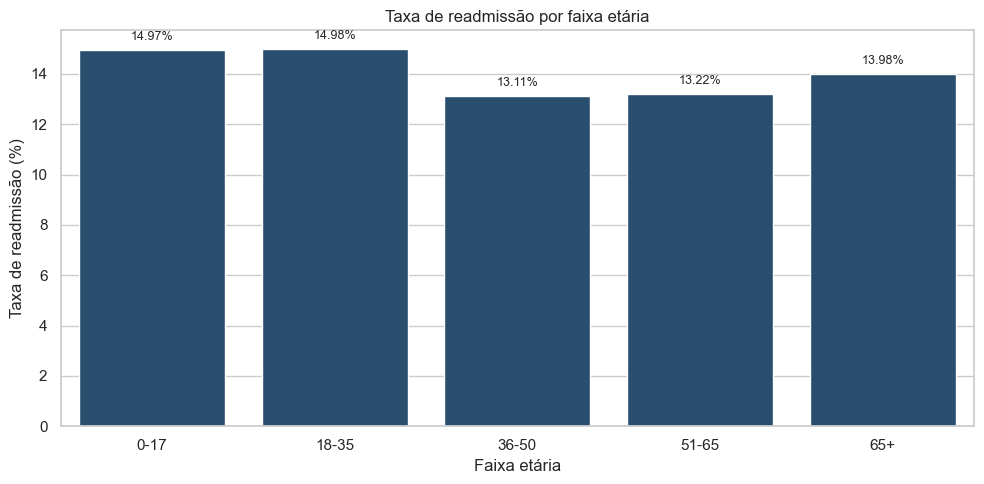

In [20]:
readmission_by_age = (
    df
    .groupby("age_group", observed=False)
    .agg(
        patients=("patient_id", "count"),
        readmission_rate=("readmitted", "mean")
    )
    .reset_index()
)

readmission_by_age["readmission_rate"] = readmission_by_age["readmission_rate"] * 100
readmission_by_age = readmission_by_age.round(2)

age_order = ["0-17", "18-35", "36-50", "51-65", "65+"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=readmission_by_age,
    x="age_group",
    y="readmission_rate",
    order=age_order,
    color="#1F4E79"
)

plt.title("Taxa de readmissão por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de readmissão (%)")

add_bar_labels_vertical(ax, "{:.2f}%")

plt.tight_layout()
plt.savefig("../outputs/charts/readmission_rate_by_age_group.png", dpi=150)
plt.show()

In [21]:
department_summary.to_csv("../outputs/tables/department_summary.csv", index=False)
satisfaction_by_wait.to_csv("../outputs/tables/satisfaction_by_wait_time.csv", index=False)
readmission_by_age.to_csv("../outputs/tables/readmission_by_age_group.csv", index=False)

df.to_csv("../data/processed/healthcare_operations_clean.csv", index=False)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.


## Leitura dos principais indicadores

A análise mostra diferenças importantes entre os departamentos.

O volume de pacientes se concentra principalmente em Emergency e General Medicine, o que indica maior pressão operacional nessas áreas.

O tempo médio de espera é mais alto em Emergency e General Medicine, sugerindo que esses departamentos podem exigir maior atenção em capacidade, triagem ou distribuição de recursos.

Departamentos como Oncology, Neurology e Cardiology apresentam maior tempo médio de permanência, o que é esperado em áreas com casos mais complexos.

A taxa de readmissão também varia entre departamentos, com destaque para áreas de maior complexidade clínica. Esse indicador pode ser acompanhado junto com tempo de permanência, perfil dos pacientes e diagnóstico.

A satisfação média tende a cair conforme aumenta o tempo de espera, reforçando a importância de monitorar esse indicador em rotinas operacionais.

## Conclusões

Este projeto simulou uma análise operacional em saúde com foco em volume de atendimentos, tempo de espera, tempo de permanência, readmissão e satisfação.

Os principais pontos observados foram:

- Emergency concentrou alto volume de pacientes e maior tempo médio de espera.
- Departamentos de maior complexidade, como Oncology, Neurology e Cardiology, apresentaram maior tempo de permanência.
- A taxa de readmissão variou entre departamentos e faixas etárias.
- A satisfação média foi menor nos grupos com maior tempo de espera.
- Indicadores operacionais simples já ajudam a identificar gargalos e pontos de atenção na operação.

## Possíveis próximos passos

- Criar um dashboard em Power BI com os principais indicadores.
- Adicionar análise mensal dos atendimentos.
- Comparar indicadores por tipo de convênio.
- Criar uma classificação simples de risco de readmissão.
- Simular metas operacionais, como tempo de espera máximo por departamento.